<a href="https://colab.research.google.com/github/mjss26/EMSC2010-Group-Project-5/blob/main/EMSC2010_Group_Project_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EMSC2010 Group Project 5 - Portfolio Version

## **Analysis of ENSO Trends 1954-2025**

## 1. Project Overview
Group name: Bugs, Bush & Biodiversity

Project week: Friday week 10 - Friday week 11

Project title: Analysis of ENSO Trends 1954-2025

Datasets used: Extended Reconstructed Sea Surface Temperature (ERSST) Version 5, National Oceanic and Atmospheric Administration (NOAA). [LINK](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927).

## 2. Roles and contributions

| Role | Primary | Deputy | Completed? | Notes |
| :--- | :--- | :--- | :--- | :--- |
| GitHub & Integration | MJ | Mia | Yes | Add note |
| Data Steward | Mia | Sonya | Yes | Add note |
| Analysis / Modelling | Sonya | Sienna | Yes | Add note |
| Visualisation / Interpretation | Sienna | Seth | Yes | Add note |
| Narrative | Seth | MJ | Yes | Add note |
| Quality Control / Reproducibility | N/A | N/A | Yes | Add note |

# **Introduction**

The project was inspired by an interest in Australia's large-scale climatic variability systems and how they affect different parts of our environment. This led to an analysis of the El Niño Southern Oscillation (ENSO) for the El Niño 3.4 region, in which variation between states of La Niña, Neutral, and El Niño affects not only the east coast of Australia, but the continent as a whole. ENSO is a periodic fluctuation (around 2-7 years) in sea surface temperature (SST) and air pressure of the atmosphere, modifying the affect of normal/expected weather conditions according to the appropriate ENSO cycle ([NOAA](https://www.ncei.noaa.gov/access/monitoring/enso/))



## **Aim and Methods**

**Research Question**

Can we identify trends in ENSO cycles using time-series analysis, including identifying frequency anaomolies in Sea Surface Temperature relevant to Australia (Region 3.4)?

**Aim**

The aim of the analysis is to apply a moving average to the SST data (1854-2025) in order to smooth out the noise, making it possible to identify ENSO cycles, which are defined largely by anomalies in SST.

**Data Methods**


To investigate the research question, a database from the National Oceanic and Atmospheric Administration (NOAA) containing El Niño and Sea Surface Temperature (SST) data was identified. The online dataset (available here: [LINK](https://www.ncei.noaa.gov/pub/data/cmb/ersst/v5/index/ersst.v5.el_nino.sst.dat)) was converted into an Excel sheet using ChatGPT, with metadata and FAIR data principles included. The dataset includes monthly SST measurements for different El Niño regions from 1854 to April 2026 and is updated on a continuous basis. The dataset was narrowed for analysis to include only SST data points from January 1854 to December 2025, with focus on the El Niño 3.4 region. The El Niño 3.4 region was selected because this region has the greatest impact on Australia's climate, and is used by the Bureau of Meteorology (BoM) for ENSO forecasting (sources: [BoM](https://www.bom.gov.au/climate/enso/?ninoIndex=nino3.4&index=rnino34&period=weekly), [NOAA](https://www.ncei.noaa.gov/access/monitoring/enso/sst)). Therefore, this project conducts a time-series analysis that can be representative of Australia's ENSO climate trends and cycles.  
* [Data Source](https://www.ncei.noaa.gov/access/metadata/landing-page/bin/iso?id=gov.noaa.ncdc:C00927)

* Citation: Boyin Huang, Peter W. Thorne, Viva F. Banzon, Tim Boyer, Gennady Chepurin, Jay H. Lawrimore, Matthew J. Menne, Thomas M. Smith, Russell S. Vose, and Huai-Min Zhang (2017): NOAA Extended Reconstructed Sea Surface Temperature (ERSST), Version 5. [elnino.sst.data]. NOAA National Centers for Environmental Information. doi:10.7289/V5T72FNM [Accessed 15/5/2026].


---

**Additional Sources:**

https://www.bom.gov.au/climate/change/about/sst_timeseries.shtml

https://journals.ametsoc.org/view/journals/clim/30/20/jcli-d-16-0836.1.xml

https://www.bom.gov.au/climate/history/enso/

# **Analysis**

### Data Loading and Initial Inspection

The following code cell loads the sea surface temperature (SST) data from an Excel file into a pandas DataFrame and displays the first few rows to give an initial overview of the dataset structure.

In [ ]:
#import packes for analysis
import numpy as np # NumPy for numerical computing
import matplotlib.pyplot as plt #plotting library
import pandas as pd #Pandas for data handling

In [ ]:
#reading in data file and creating dataframe
file = 'ERSST_El_Nino_SST_Data.xlsx' #read in data excel file
df = pd.read_excel(file, sheet_name='Sheet1') #read file and 'Sheet1' into df
df.head() #show the header information

,Year,Month,Nino1.2_SST (℃),Nino3_SST (℃),Nino3.4_SST (℃),Nino4_SST (℃),Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,1854,1,25.46,27.69,25.90,23.97,NaN,NaN,NaN,NaN
1,1854,2,26.12,27.77,26.06,25.54,NaN,NaN,NaN,NaN
2,1854,3,26.79,28.10,26.91,25.28,NaN,NaN,NaN,NaN
3,1854,4,27.19,28.42,27.63,23.95,NaN,NaN,NaN,NaN
4,1854,5,26.99,28.86,27.90,22.80,NaN,NaN,All El Nino Sea Surface Temperature (SST) valu...,NaN


### Data Processing: Focusing on El Niño 3.4 Region

This section extracts the relevant 'Year', 'Month', and 'Nino3.4_SST (℃)' columns, drops any rows with missing values, and converts the data into NumPy arrays for further numerical processing. It also combines 'Year' and 'Month' to create a continuous 'year' variable for time-series analysis.

In [ ]:
# Creating dataframe with values we are interested in: Year, Month, year El Niño sea surface temperature (°C) for region 3.4

df_sst = df[['Year', 'Month', 'Nino3.4_SST (℃)']].copy()
df_sst = df_sst.dropna() #remove rows with NaN missing values
Year = df_sst['Year'].to_numpy() #convert years into numpy array
month = df_sst['Month'].to_numpy() #convert months into numpy array
sst = df_sst['Nino3.4_SST (℃)'].to_numpy() #convert sst into numpy array

#Converting Year, Month, into 'year' = Year + Month / 12
df_sst['year'] = (df_sst['Year'] + df_sst['Month']/12).round(2) #create value for time as year.month and round to 2 decimal place
year = df_sst['year'].to_numpy() #convert year.month into numpy array

df_sst.head() # Show the header information

,Year,Month,Nino3.4_SST (℃),year
0,1854,1,25.90,1854.08
1,1854,2,26.06,1854.17
2,1854,3,26.91,1854.25
3,1854,4,27.63,1854.33
4,1854,5,27.90,1854.42


### Visualizing Raw Sea Surface Temperature Data



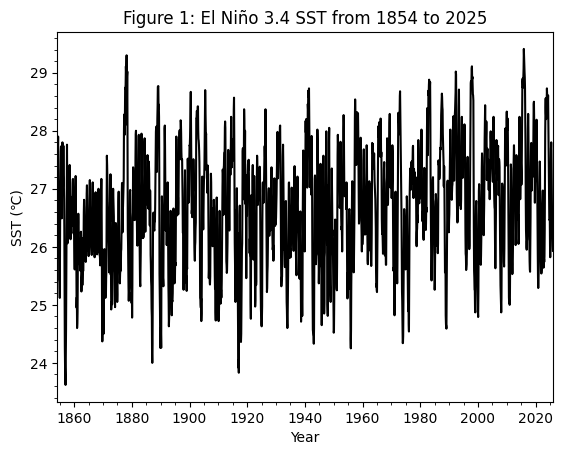

In [ ]:
# plot to check dataframe

plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('Figure 1: El Niño 3.4 SST from 1854 to 2025')
plt.minorticks_on()
plt.xlim(1854, max(year)) #Set x-axis limit to start from 1854
plt.show()

### *Figure 1: El Niño 3.4 SST from 1854 to 2025*

This plot visualises the raw SST data for the El Niño 3.4 region from 1854 to 2025. This initial visualisation helps to observe the overal patterns and any prominent fluctuations in the data over time.



### Zooming In on Recent SST Data (1980-2025)



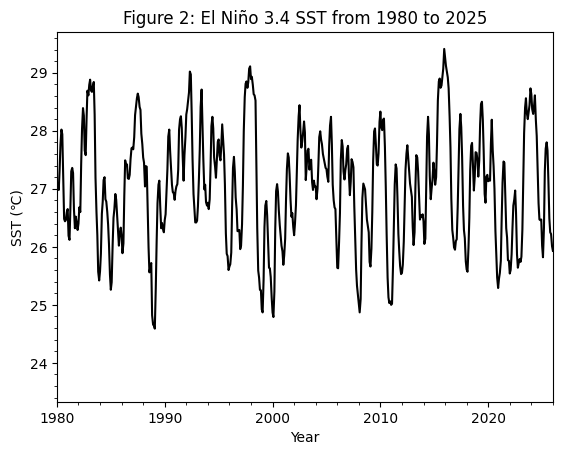

In [ ]:
#zoom in on data
plt.plot(year,sst,'black') #Plot year and sst data
plt.xlabel('Year')
plt.ylabel('SST (℃)')
plt.title('Figure 2: El Niño 3.4 SST from 1980 to 2025')
plt.minorticks_on()
plt.xlim(1980, max(year)) #Set x-axis limit to start from 1980
plt.show()

### *Figure 2: El Niño 3.4 SST from 1980 to 2025*

This plot provides a more detailed view of the SST data from 1980 to 2025, allowing for closer inspection of recent trends and variations that might be less apparent in the full-timescale historical plot.

### Polynomial Fit for Overall Trend

Here, a polynomial of order 40 is fitted to the raw SST data. This polynomial trend line helps capture the long-term, broader movements in sea surface temperatures, abstracting away short-term fluctuations. The polynomial order 40 was chosen through a visual assessment (eyeballing), checking the fit of the polynomial order was neither overfitted (order=100 inappropriate) or underfitted (order=4 inappropriate).

In [ ]:
order = 40 #set the polynomial order
pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients
trend = np.polyval(pp,year) #find the value of the polynomial at each time point.

/tmp/ipykernel_10796/420706993.py:2: RankWarning: Polyfit may be poorly conditioned
  pp = np.polyfit(year,sst,order) #fit the polynomial, pp will contain the polynomial coefficients


### Sea Surface Temperature with Moving Average and Polynomial Trend



/tmp/ipykernel_10796/1777931099.py:14: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend


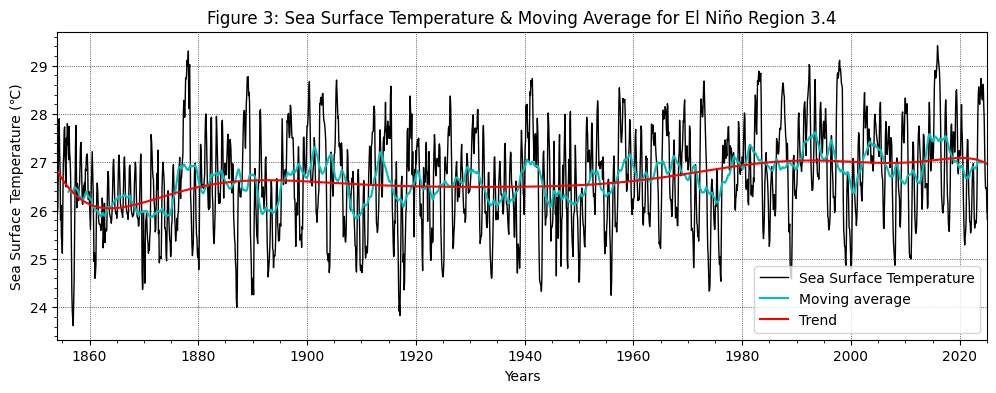

In [ ]:
#Sea Surface Temp (SST) raw data, moving average, and polynomial trend plotted to visualise correlation

#using data from dataframes; 'year' and 'sst'
def moving_average(sst,w):
  return np.convolve(sst, np.ones(w), 'valid' ) / w #moving average function

w = 50 #length of the moving average
p_sst = moving_average(sst, w) #process the sst
p_year = moving_average(year, w) #process the time

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,sst,'k',linewidth=1,label='Sea Surface Temperature') #plot the raw data
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(year,trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Figure 3: Sea Surface Temperature & Moving Average for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

### *Figure 3: Sea Surface Temperature & Moving Average for El Niño Region 3.4*

This graph combines the raw SST data with a 50-point moving average and the previously calculated polynomial trend. The moving average is applied to smooth out short-term noise, making the underlying ENSO cycles and long-term trends more visible. A moving average parameter ('w') of 50 was chosen because it visually presented an appropriate period of time to 'smooth' averages considering the period of historical data (171 years). This result visually removed enough noise so results appear 'meaningful', but not too much so as the results appear 'meaningless'. This selection is highly subjective to visual interpretation.

Figure 3 shows the general increasing trend in SST in El Niño 3.4 from 1854-2025 - shown by the polynomial 'Trend' (red line). It also displays a 'cleaner' representation of SST data, filtering high- and low- frequency 'noise' using a 50 point moving average (teal line).  

### Polynomial Fit for Moving Average Trend

Similar to the raw data, a polynomial of order 40 is fitted to the moving average of the SST data. This provides a smoothed trend line specifically for the averaged data, further highlighting the longer-term patterns within the smoothed signal.

In [ ]:
p_order = 40 #set the polynomial order
p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients
p_trend = np.polyval(p_pp,p_year) #find the value of the polynomial at each time point.

/tmp/ipykernel_10796/3443567569.py:2: RankWarning: Polyfit may be poorly conditioned
  p_pp = np.polyfit(p_year,p_sst,p_order) #fit the polynomial, pp will contain the polynomial coefficients


### Moving Average of Sea Surface Temperature with its Polynomial Trend


/tmp/ipykernel_10796/2754170377.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r" (-> color=(1.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend


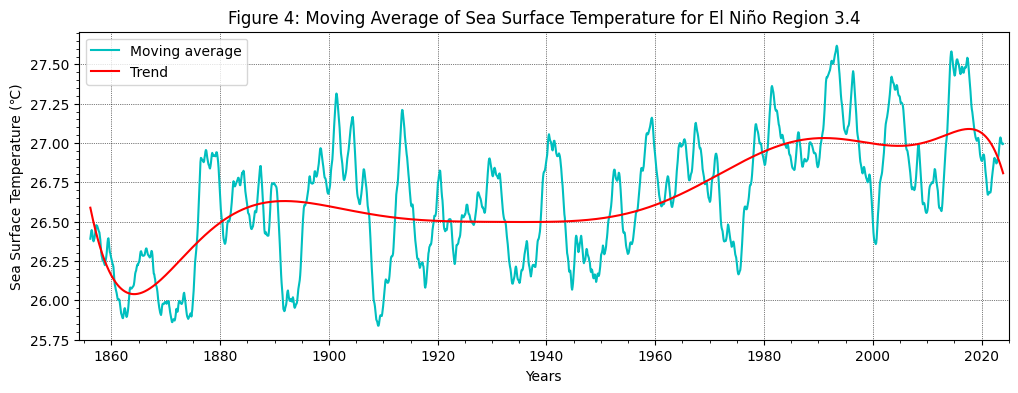

In [ ]:
#SST moving average (w=50) data, with a fitted polynomial trend (w=40), no raw data to increase readability

plt.figure(figsize=(12, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(p_year,p_sst,'c',label='Moving average') #plot the moving average
plt.plot(p_year,p_trend,'r',label='Trend', color='red') #plot the trend
plt.xlim([1854,2025]) #limit the x-axis
plt.title('Figure 4: Moving Average of Sea Surface Temperature for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature (℃)') #label the y-axis
plt.legend() #add a legend
plt.minorticks_on() #add minorticks
plt.grid(which='major', linestyle=':', linewidth='0.5', color='black')

### *Figure 4: Moving Average of Sea Surface Temperature for El Niño Region 3.4*

This plot focuses solely on the moving average and the polynomial trend, removing the raw data to improve readability. This clearer view helps in analyzing the cyclical patterns identified after noise reduction. It utilises the same parameters as Figure 3, where 'order=40' and 'w=50'.

Figure 4 shows the moving average was successful in eliminating 'noise' from the ENSO data.


### Calculating the SST Baseline Trend and Anomalies

To understand deviations from normal conditions, a baseline sea surface temperature is calculated using the mean SST from 1991 to 2020. This period is chosen to align with common climatological baselines, such as those used by the Bureau of Meteorology (BoM).

In [ ]:
#baseline for sst anomoly calculated from 30 year rolling climatology baseline. BoM currently uses 1991-2020 (I know that's only 29 years but that's what the BoM website says)

sst_1991_2020 = df_sst[(year >= 1991) & (year <= 2020)] #sst data from 1991-2020
baseline = sst_1991_2020['Nino3.4_SST (℃)'].mean()
print(baseline)

27.094957020057304


### Plotting Sea Surface Temperature Anomalies



(1854.0, 2025.0)

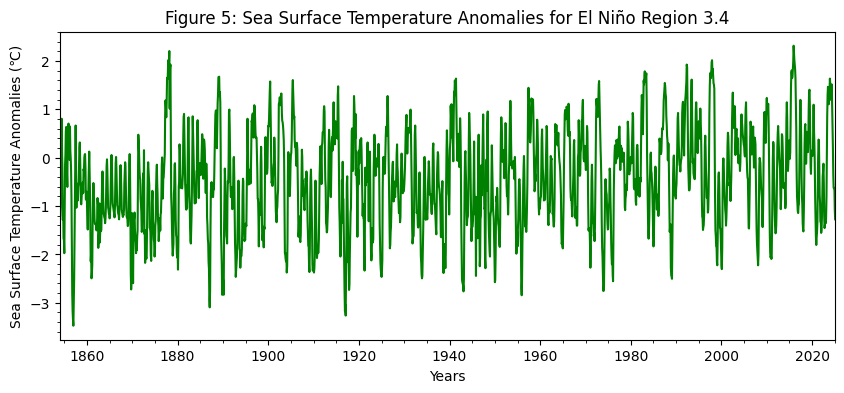

In [ ]:
#problem calculating anomaly fixed
anomalies = sst - baseline #calculate anomaly using array broadcasting

plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,'g') #plot the anomalies
plt.title('Figure 5: Sea Surface Temperature Anomalies for El Niño Region 3.4')
plt.xlabel('Years') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

### *Figure 5: Sea Surface Temperature Anomolies for El Niño Region 3.4*

The above cell calculates and plots the sea surface temperature anomalies, which are the differences between the raw SST data and the calculated baseline (27.09 degrees C). Anomalies are crucial for identifying periods of **El Niño (positive anomalies)** and **La Niña (negative anomalies)**. Sea Surface Temperature anomolies are represented in Figure 5.

### Sea Surface Temperature Baseline Trend



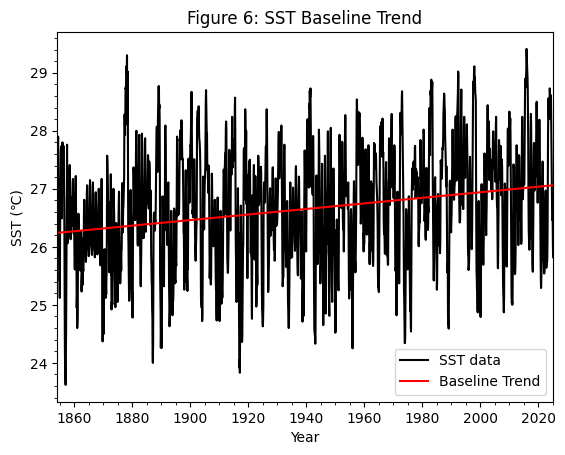

In [ ]:
#plot the raw SST data with a linear trendline
fitter1 = np.polyfit(year,sst,1) #fit a trendline to the data
plt.plot(year,sst,'k', label='SST data') #plot the original data
plt.plot(year,np.polyval(fitter1,year),'r', label='Baseline Trend') #plot the trendline
plt.xlim(1854, 2025)
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST (℃)') #label the y-axis
plt.title('Figure 6: SST Baseline Trend')
plt.legend()
plt.minorticks_on() #add minorticks

### *Figure 6: SST Baseline Trend*

In Figure 6 a linear trendline is fitted to the raw SST data to illustrate the overall long-term change in sea surface temperatures. This provides a simple visual representation of whether temperatures are increasing, decreasing, or remaining stable over the entire period. The linear trendline indicates that **sea surface temperature is gradually increasing over time for the El Niño Region 3.4**.

### Essential Signal Processing Functions

Utilising the moving average of raw SST data (smoothed data) and SST anomolies, we can begin to investigate **frequencies in ENSO cycles**.

The below cell codes and defines two key functions for spectral analysis: ``freq_spectrum`` to calculate the frequency spectrum of a signal, and `lowpass_filter` to remove high-frequency noise. These functions are instrumental in identifying underlying periodicities and smoothing signals in time-series data.

In [ ]:
def freq_spectrum(time,signal):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT (positive freqs only)
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  # Amplitude: scale by 2/n so each peak height equals the true amplitude
  amplitude = (2 / n) * np.abs(fft_vals)
  amplitude[0] /= 2

  return freqs, amplitude

def lowpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs>cutoff] = 0.0 #cycles above the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

# The following functions are commented out as they were not used in the final analysis.

def highpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

  #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff] = 0.0 #cycles below the frequency cutoff are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

def bandpass_filter(time,signal,cutoff):

  n = len(time) #number of data points

 #interpolate data onto uniformly spaced time
  x = np.linspace(np.min(time),np.max(time),n)
  y = np.interp(x,time,signal)

  sample_rate = 1 / (x[1]-x[0]) #sampling rate
  fft_vals  = np.fft.rfft(y)    #FFT
  freqs     = np.fft.rfftfreq(n, d=1/sample_rate) #frequencies

  fft_vals[freqs<cutoff[0]] = 0.0 #cycles below cutoff[0] are given an amplitude of 0
  fft_vals[freqs>cutoff[1]] = 0.0 #cycles above cutoff[1] are given an amplitude of 0

  filtered_signal = np.fft.irfft(fft_vals, n=len(time)) #IFFT

  return x, filtered_signal

### Frequency Spectrum of Raw SST



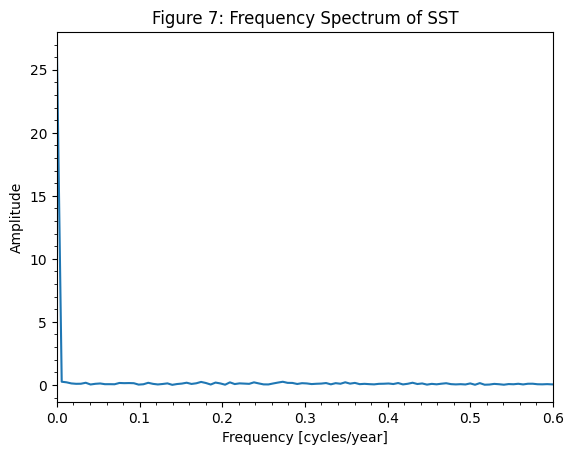

In [ ]:
#plot raw SST data frequency
freqs, amps = freq_spectrum(year,sst) #calculate the frequency spectrum
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency [cycles/year]') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Figure 7: Frequency Spectrum of SST')
plt.xlim([0,0.6]) #limits the x-axis to show relevant ENSO frequencies
plt.minorticks_on() #add minorticks

### *Figure 7: Frequency Spectrum of SST*

Figure 7 displays the frequency spectrum of the raw SST data. Analyzing the frequencies present in the signal will help identify dominant periodic cycles, which are indicative of phenomena like ENSO. The x-axis represents frequency in cycles per year, with an expanded range to better visualize key cyclical patterns.

It is important to note the initial large amplitude at the zero-frequency component (`Frequency[0.0]`). This represents the general trend of the SST signal. Large general trends like this could be due to a large number of converging factors. One of these factors could be climate change which has happened exponentially since the industrial revolution and will increase as time continues. Another of these potential factors could be general milankovitch cycles, which occur at scales much larger than our analysis and data would allow us define, thousands to tens of thousands of years.

### Frequency Spectrum of Detrended SST with Significant ENSO Cycles

In the below cell, the SST data is `detrended` by subtracting the linear trend. The `frequency spectrum` of this detrended data is then plotted, with an extended x-axis in comparison to Figure 7 (Figure 7 x-axis is limited at 0.6, where Figure 8 x-axis is extended to 1.0).

The frequency spectrum plot reveals the dominant periodicities within the raw Sea Surface Temperature (SST) data. Meaning, the peaks in amplitude correspond to the most significant cycles. There should be visually observed peaks around 0.1 to 0.5 cycles/year, which align with the known frequency range of the ENSO phenomenon (typically 2-7 years, or approximately 0.14 to 0.5 cycles/year). **This indicates that ENSO is a major driver of variability in the SST data for the El Niño 3.4 region.**

Vertical lines are included in the plot to mark approximate frequencies of significant ENSO cycles. This was completed through visual assessment and is therefore a subjective approximation. The vertical markers highlight five high-frequency peaks observed in the data, two of the most extreme markers are highlighted in green at frequencies (0.17) and (0.51). All markers were tested with in our analysis, however these most extreme frequencies were chosen for the final analysis. These frequency markers help to identify significant high-frequency periods in the detrended ENSO data, which will be analysed and investigated.






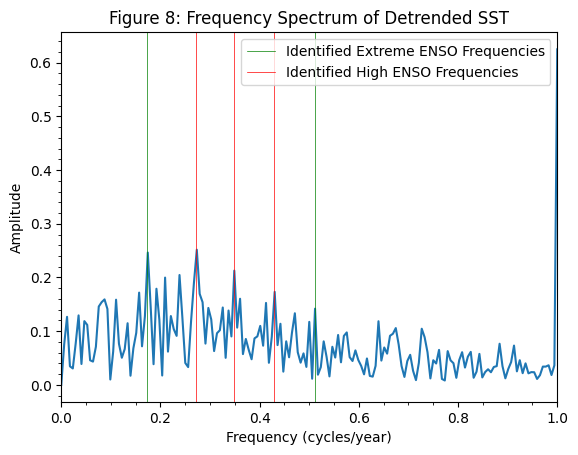

In [ ]:
#calculate a detrended version of the SST data, and plot its frequency
detrend = sst-np.polyval(fitter1,year) #calculate the detrended data
freqs, amps = freq_spectrum(year,detrend) #frequency spectrum of the detrended data
plt.plot(freqs,amps) #plot the frequency spectrum
plt.xlabel('Frequency (cycles/year)') #label the x-axis
plt.ylabel('Amplitude') #label the y-axis
plt.title('Figure 8: Frequency Spectrum of Detrended SST')
plt.xlim([0,1.0]) #limits the x-axis
plt.minorticks_on() #add minorticks

#marking frequencies
#plt.gca().axvline(x=1/10,color='blue', label='Previous x-limit (0.1 cycles/year)') #Mark 0.1 in blue for legibility (Previous frequency spectrum x limit)
plt.gca().axvline(x=1/5.76,color='g',linewidth=0.5, label='Identified Extreme ENSO Frequencies') #mark another frequency (ENSO 1)
plt.gca().axvline(x=1/3.67,color='r',linewidth=0.5, label='Identified High ENSO Frequencies') #mark another frequency (ENSO 2)
plt.gca().axvline(x=1/2.88,color='r',linewidth=0.5) #mark another frequency (ENSO 3)
plt.gca().axvline(x=1/2.33,color='r',linewidth=0.5) #mark another frequency (ENSO 4)
plt.gca().axvline(x=1/1.955,color='g',linewidth=0.5) #mark another frequency (ENSO 5)
plt.legend()

### *Figure 8: Frequency Spectrum of Detrended SST*

Figure 8 plots the `detrended` SST data as a frequency, and identifies and highlights high and extreme frequency peaks (red and green x-axis markers respectively) over the ENSO cycle.

### Filtered ENSO Trend (Band-Pass Filtered Detrended SST)

The below cell plots the detrended SST data after applying a `band-pass filter` with a cutoff frequency **corresponding to ENSO precession cycles (1/5.760 and 1/1.955 years)**. This filtering highlights the oscillations that only occur between these values, effectively isolating the ENSO trend from both higher and lower frequency noise.

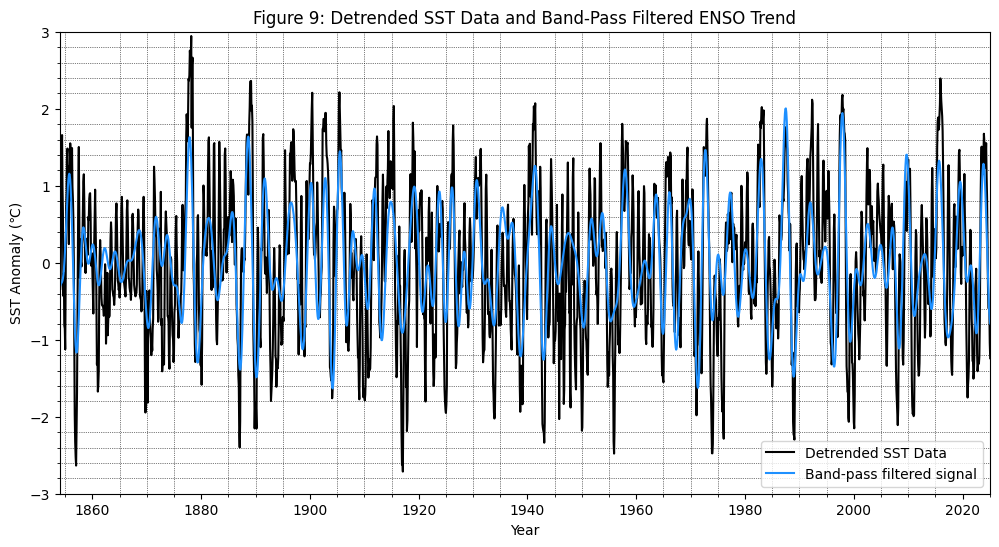

In [ ]:
#plotting the detrended SST data and low-pass filter trend
plt.figure(figsize=(12, 6)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,detrend, color='k', label='Detrended SST Data') #plot the detrended data
x, y = bandpass_filter(year,detrend,[1/5.76,1/1.955]) #obtain the filtered signal
plt.plot(x,y, color='dodgerblue', label='Band-pass filtered signal') #plot the filtered signal
plt.legend() #add legend
plt.xlim(1854, 2025) #x limit
plt.ylim(-3, 3) #y limit
plt.xlabel('Year') #label the x-axis
plt.ylabel(r'SST Anomaly (℃)') #label the y-axis
plt.title('Figure 9: Detrended SST Data and Band-Pass Filtered ENSO Trend')
#plt.gca().invert_yaxis() #invert the y-axis
#plt.xlim([0,800]) #limit the x-axis
plt.minorticks_on() #add minorticks
plt.grid(which='minor', linestyle=':', linewidth='0.5', color='black')

### *Figure 9: Detrended SST Data and Band-Pass Filtered ENSO Trend*

Figure 9 displays the detrended Sea Surface Temperature (SST) data alongside a band-pass filtered signal. The detrended data removes the long-term warming trend shown in Figure 6, allowing for a clearer observation of cyclical variations. The band-pass filtered signal further smooths these variations, effectively isolating the underlying ENSO trend from higher and lower frequency noise and highlighting its periodic nature.



### Sea Surface Temperature Anomalies and Filtered ENSO Trend

The visualization in Figure 10 overlays the sea surface temperature anomalies (Figure 5) with the filtered ENSO trend (Figure 9). This allows for a direct comparison between the observed deviations from the baseline and the smoothed, underlying ENSO cycles, providing insight into how closely the trends align.

(1854.0, 2025.0)

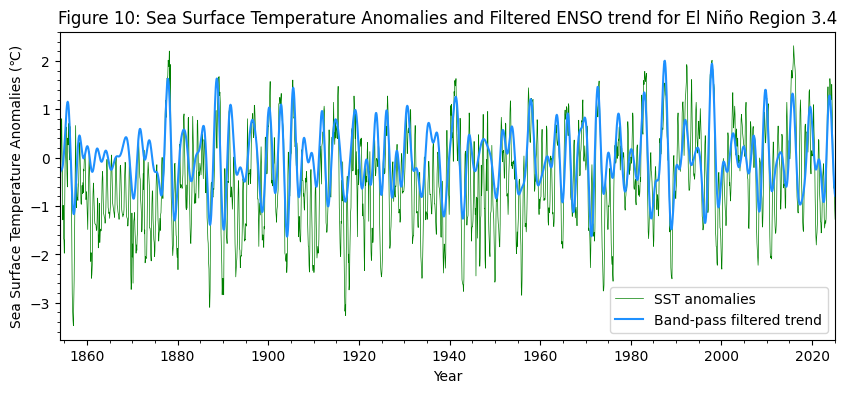

In [ ]:
#plot SST anomalies and low-pass filtered ENSO trend
plt.figure(figsize=(10, 4)) #figure used to 'stretch out' x-axis and make data less cramped
plt.plot(year,anomalies,color='g',linewidth=0.5, label='SST anomalies') #plot the anomalies
plt.plot(x,y,color='dodgerblue', label='Band-pass filtered trend') #plot the filtered signal
plt.legend() #add legend
plt.title('Figure 10: Sea Surface Temperature Anomalies and Filtered ENSO trend for El Niño Region 3.4')
plt.xlabel('Year') #label the x-axis
plt.ylabel('Sea Surface Temperature Anomalies (℃)') #label the y-axis
plt.minorticks_on() #add minorticks
plt.xlim([1854,2025]) #limit the x-axis

### *Figure 10: Sea Surface Temperature Anomalies and Filtered ENSO trend for El Niño Region 3.4*

Figure 10 shows the anomalies in SST and the band-pass filtered ENSO trend. This demonstrates a close alignment of SST anomalies, which define ENSO cycles, and the filtered ENSO trend.

### Visualization: SST, Moving Average, and Filtered ENSO Trend

This comprehensive plot brings together the raw SST data, the 50-point moving average, and the filtered ENSO trend (adjusted to align with the SST scale for easier comparison). This visualization offers a complete picture of the SST variations, noise reduction, and the identified cyclical patterns related to ENSO over the entire study period.

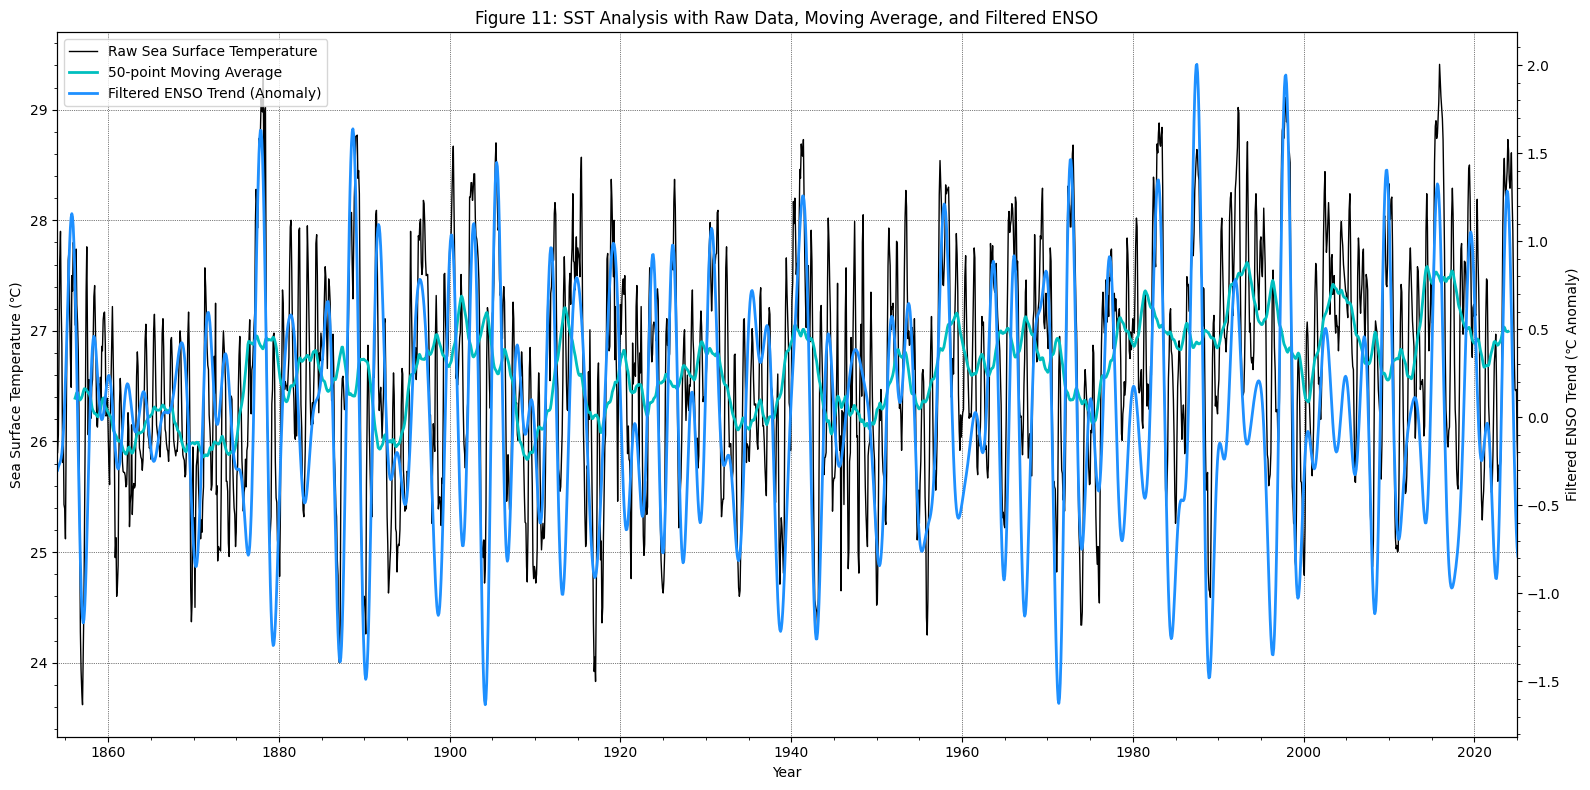

In [ ]:
plt.figure(figsize=(16, 8))

# Primary Y-axis for actual SST values
ax1 = plt.gca()
ax1.plot(year, sst, 'k', linewidth=1, label='Raw Sea Surface Temperature')
ax1.plot(p_year, p_sst, 'c', linewidth=2, label='50-point Moving Average')
#ax1.plot(year, trend, 'r', linewidth=2, label='Overall Polynomial Trend (Order 40)') # Overall polynomial trend for raw SST
ax1.set_ylabel('Sea Surface Temperature (℃)')
ax1.set_xlabel('Year')
ax1.minorticks_on()
ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.set_xlim([1854, 2025])

# Create a secondary Y-axis for the Filtered ENSO Trend (Anomaly)
ax2 = ax1.twinx()
# 'y' is the low-pass filtered detrended data, which represents the ENSO signal as an anomaly.
ax2.plot(x, y, color='dodgerblue', linewidth=2, label='Filtered ENSO Trend (Anomaly)') # (linestyle='--') removed
ax2.set_ylabel('Filtered ENSO Trend (℃ Anomaly)')
ax2.minorticks_on()

# Combine legends from both axes to appear on one legend box
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Figure 11: SST Analysis with Raw Data, Moving Average, and Filtered ENSO')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.xlim([1854, 2025])
plt.show()

### *Figure 11: SST Analysis with Raw Data, Moving Average, and Filtered ENSO*

This plot provides a multi-layered view of the El Niño 3.4 Sea Surface Temperature (SST) data. It overlays the raw SST, the 50-point moving average to smooth out noise, and the filtered ENSO trend (displayed on a secondary y-axis to represent anomalies). This allows for a direct comparison of the immediate sea surface temperature variations, the underlying cyclical patterns of ENSO, and the overall noise reduction achieved through filtering and moving averages.

### Comprehensive Visualisation: Combining Analysis with Real ENSO Periods (1980-2025)

The below comprehensive plot combines results of the above analysis with real ENSO periods reported by BoM, accurate to the month ([BoM](https://www.bom.gov.au/climate/history/enso/)). This allows for a direct comparison of the analytical findings, including the raw SST data, 50-point moving average, and band-pass filtered ENSO trend, with documented historical ENSO events. The comprehensive plot has also been limited to the period of 1980-2025 rather than 1984-2025, so ENSO cycles can more easily be identified and interpereted.

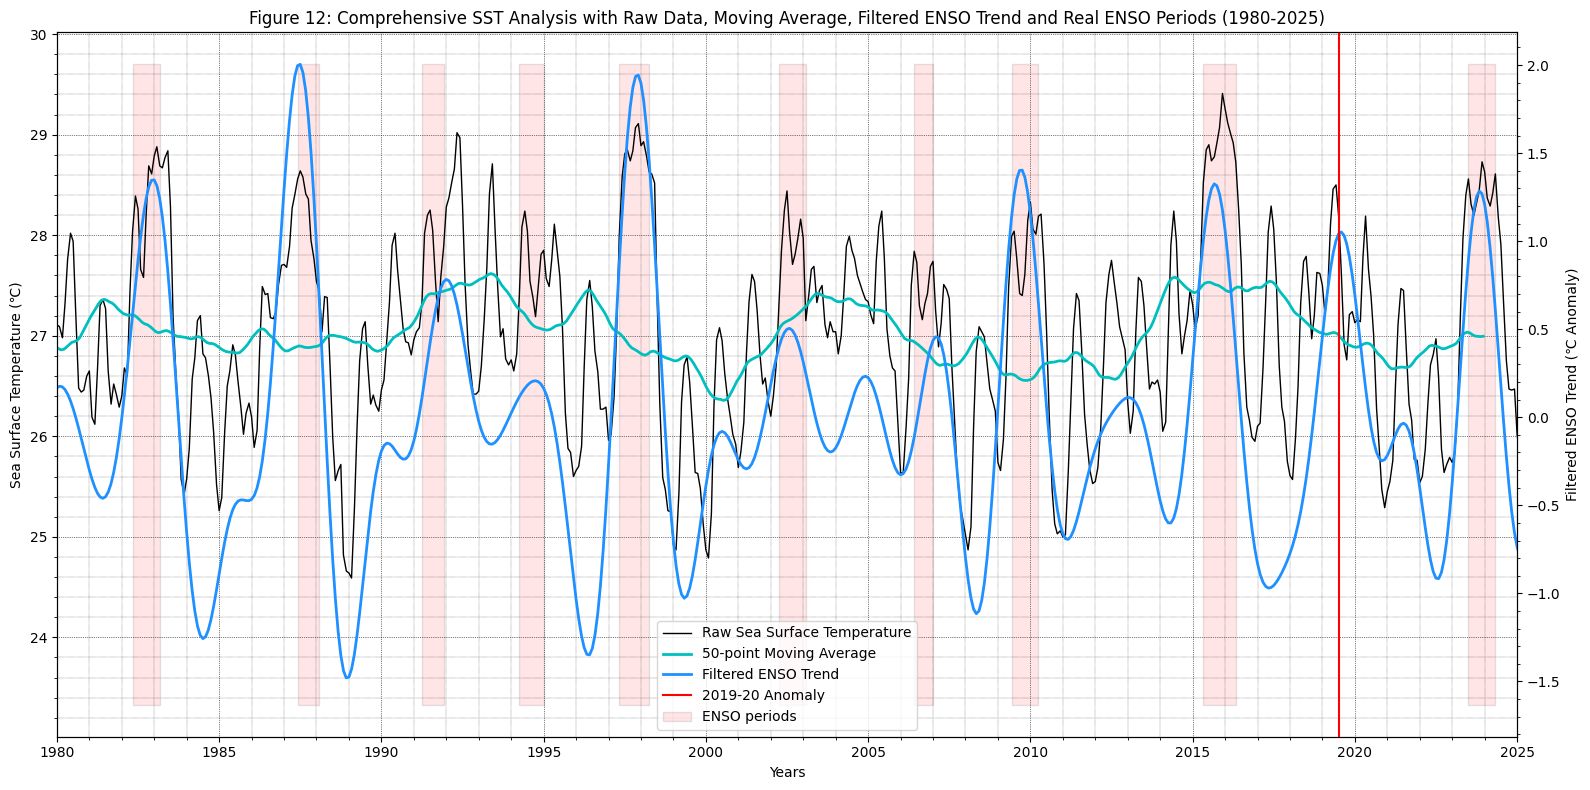

In [ ]:
#Comprehensive plot with a zoom-up (1980-2025) to better identify ENSO cycles

import matplotlib.patches as mpatches
import matplotlib.lines as mlines

plt.figure(figsize=(16, 8))

# Primary Y-axis for actual SST values
ax1 = plt.gca()
ax1.plot(year, sst, 'k', linewidth=1, label='Raw Sea Surface Temperature')
ax1.plot(p_year, p_sst, 'c', linewidth=2, label='50-point Moving Average')
#ax1.plot(year, trend, 'r', linewidth=2, label='Overall Polynomial Trend (Order 40)') # Overall polynomial trend for raw SST
ax1.set_ylabel('Sea Surface Temperature (℃)')
ax1.set_xlabel('Years')
ax1.minorticks_on()
ax1.grid(which='major', linestyle=':', linewidth='0.5', color='black')
ax1.grid(which='minor', linestyle=':', linewidth='0.3', color='black')
ax1.set_xlim([1854, 2025])

# Create a secondary Y-axis for the Filtered ENSO Trend (Anomaly)
ax2 = ax1.twinx()
# 'y' is the low-pass filtered detrended data, which represents the ENSO signal as an anomaly.
ax2.plot(x, y, color='dodgerblue', linewidth=2, label='Filtered ENSO Trend') # (linestyle='--') removed
ax2.set_ylabel('Filtered ENSO Trend (℃ Anomaly)')
ax2.minorticks_on()

plt.title('Figure 12: Comprehensive SST Analysis with Raw Data, Moving Average, Filtered ENSO Trend and Real ENSO Periods (1980-2025)')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.xlim([1980, 2025])

# Existing axvline and fill_between calls
# Create proxy artists for the legend
# For axvline
proxy_vline = mlines.Line2D([], [], color='r', linestyle='-', label='2019-20 Anomaly')
plt.gca().axvline(x=2019.5, color='r') # Black Summmer

# Get the y-limits of the primary axis to span the fill vertically
ax1_ymin, ax1_ymax = ax1.get_ylim()

# For fill_between - they all have the same style, so one proxy is enough
proxy_fill = mpatches.Rectangle((0, 0), 1, 1, facecolor='red', edgecolor='black', alpha=0.1, label='ENSO periods')

ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2023-2024
                 where=(year >= 2023.5) & (year <= 2024.33),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2015-2016
                 where=(year >= 2015.33) & (year <= 2016.33),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 2009.42) & (year <= 2010.25),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 2006.42) & (year <= 2007),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 2002.25) & (year <= 2003.08),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 1997.33) & (year <= 1998.25),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 1994.25) & (year <= 1995),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 1991.25) & (year <= 1991.92),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 1987.42) & (year <= 1988.08),
                 color='red', edgecolor='black', alpha=0.1
)
ax1.fill_between(year, ax1_ymin, ax1_ymax, #Fill for 2009-2010
                 where=(year >= 1982.33) & (year <= 1983.17),
                 color='red', edgecolor='black', alpha=0.1
)

# Combine legends from both axes and add new proxy artists
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

# Append the proxy artists to the handles and labels lists
all_handles = lines + lines2 + [proxy_vline, proxy_fill]
all_labels = labels + labels2 + [proxy_vline.get_label(), proxy_fill.get_label()]

ax2.legend(all_handles, all_labels, loc='lower center')

plt.show()

### *Figure 12: Comprehensive SST Analysis with Raw Data, Moving Average, Filtered ENSO Trend and Real ENSO Periods (1980-2025)*

Figure 12 shows an in-depth analysis of El Niño 3.4 Sea Surface Temperatures (SST) from 1980 to 2025, integrating raw data, a 50-point moving average, and a filtered ENSO trend, alongside official ENSO period annotations. This allows for a direct comparison of the analytical findings with documented historical ENSO events, **highlighting the strong correlation between the filtered trend and actual El Niño and La Niña occurrences**.
* El Niño periods are shown in the peaks of raw SST data (black plot) and the filtered ENSO trend (blue signal), which is directly supported by official identified ENSO periods (red shaded regions).
* La Niña periods are thereby shown and implied in the troughs of raw SST data (black plot) and the filtered ENSO trend (blue signal). This aligns with offical indentified ENSO periods, as La Niña occurs between two known occurances of ENSO.  
* Likewise, Transition periods between El Niño and La Niña events can be inferred and would be seen to occur at the slopes of the filtered trend.

* The red vertical line on the x-axis indicates a significant anomaly in the raw SST data and filtered ENSO trend, where there is no official recorded ENSO period by BoM. This anomaly occurred in 2019-20, when the Black Summer Bushfires occurred in Australia. This anomaly could be a factor of other converging climate drivers or due to climate change impacting ENSO behaviour. This is supported by the extreme climatic occurences and events that happened during that time period, including the Australian Black Summer Bushfires.

**Figure 12 demonstrates that while ENSO Region 3.4 experiences  long-term warming, short to medium-term SST variations are predominantly shaped by the natural, cyclical patterns of the ENSO phenomenon**. The use of a secondary y-axis for the anomaly trend significantly improves the clarity of this relationship.


# **Discussion**

The timeseries analysis successfully demonstrated long-term ENSO trends for ENSO Region 3.4. This was acheived through applying a moving average and identifying anomalies in raw SST data, analying the frequency of detrended SST data, and using a low-pass filter to identify the underlying ENSO trend.

Figure 12 effectively consolidates several layers of timeseries analysis, offering signficant conclusions regarding the dynamics of El Niño Region 3.4 Sea Surface Temperatures (SST):

1.  **Clear Identification of ENSO Cycles:** Figure 12  displays the El Niño-Southern Oscillation (ENSO) cycles through the *Filtered ENSO Trend (Anomaly)*. The distinct peaks (El Niño) and troughs (La Niña) provide clear evidence of these recurring climatic events. The analysis shows direct alignment with official records for ENSO periods.

2.  **ENSO as a Dominant Driver:** A key insight is the striking alignment between the *50-point Moving Average* of the raw SST and the *Filtered ENSO Trend*. This strong correlation visually confirms that ENSO is a primary mechanism driving the interannual variability observed in the smoothed SST data. The 50-point moving average successfully isolates and highlights these influential cycles. This alignment is further supported by the spectral analysis (Figure 8), where dominant peaks in the frequency spectrum of detrended SST were observed at approximately 0.17 and 0.51 cycles/year, directly corresponding to known ENSO periodicities (typically 2-7 years). These identified frequencies were isolated using a bandpass filter to extract the filtered ENSO trend, ensuring that the visualized cyclical patterns accurately represent the underlying ENSO signal.

3.  **Underlying Long-Term Warming:** The *Overall Polynomial Trend* (shown in Figure 6 and Figure 11) clearly indicates a persistent, long-term warming trend in the El Niño 3.4 region's SSTs over the entire period of record (1854-2025). This trend is distinct from, but co-occurs with, cyclical ENSO variations. This long-term warming trend could be attributed to climate change and rising global average sea temperatures, a hypothesis which is being investigated by researchers [ENSO & CC](https://www.climate.gov/news-features/blogs/enso/has-climate-change-already-affected-enso).

4.  **Effective Noise Reduction:** The contrast between the noisy *Raw Sea Surface Temperature* and the smooth *50-point Moving Average* demonstrates the effectiveness of the moving average analysis in revealing underlying patterns by filtering out short-term fluctuations.

5.  **2020 ENSO Anomaly:** Figure 12 highlights an interesting anomaly in 2019-20, marked by a significant deviation in both raw SST data and the filtered ENSO trend, which did not correspond to an official recorded ENSO period by BoM. This coincided with the Black Summer Bushfires in Australia, suggesting potential localized or external climatic influences that warrant further investigation beyond typical ENSO dynamics.



# **Limitations**


This analysis provides useful insights, but there are always a few limitations. Much of our analysis for trend relationships and determining parameters (such as 'order' and 'w' for moving averages) were based on visual judgements and "That looks like a fit", and therefore are subjective. The raw SST data and filtered ENSO trend identified what seemed by-our-analysis to be an El Niño period, although this was not a official recorded ENSO period (2020). This was noted in our discussion as a potential impact of the Black Summer Bushfires, but this is more a suggestion/guess and requires further research. This analysis only considers ENSO SST data for Region 3.4, which could be expanded to analyse other ENSO Regions for a more comprehensive analysis of ENSO periodic cycles globally.






# **Conclusion**

This project achieved its aim of identifying ENSO cycles and long-term trends utilising timeseries analysis. The El Niño Southern Oscillation (ENSO) Region 3.4 was analysed utilising Sea Surface Temperature (SST) data from 1854 to 2025. Through moving averages, spectral analysis, detrending frequencies, and applying filters, we successfully identified and characterized the complex long-term trends and cycles of ENSO patterns.

The analysis summarised in Figure 12 revealed several key insights:

* **Identification of ENSO Cycles and Trends:** The analysis was able to clearly identify long-term trends and cycles in SST data for El Niño Region 3.4, demonstrating expected ENSO patterns.

*  **Dominance of ENSO Cycles:** The strong alignment between the 50-point moving average and the filtered ENSO trend with offical ENSO occurrences underscores that ENSO is a primary driver of SST variability across Region 3.4.
*  **Persistent Warming Trend:** An overarching long-term polynomial trend clearly demonstrates consistent SST warming over the entire study period, indicating a broader climatic shift occurring in parallel with natural ENSO oscillations.


Analysis of ENSO trends have significant implications, particularly for Australia, whose climate is profoundly influenced by the El Niño 3.4 Region. Understanding these trends and cycles is crucial for improving climate forecasting, preparing for extreme weather events (such as droughts and floods), and informing long-term environmental management strategies. The project highlights the importance of understanding the weather impacts of influential phenomena like ENSO, to predict and prepare for climatic variations.

# **Group Reflections**

Note: Roles listed in brackets were done in addition to primary role. **This notebook was edited for portfolio submission by MJ, Mia, Sienna, and Seth.**

**Mia - Data Steward**: I expected to find the data steward role challenging and I was correct! I found it difficult at first to define the scope of the project and find appropriate themes or concepts we could use for time-series analysis that our group would find interesting. I also ran into difficulties finding accessible datasets, and when I found them they were often poorly formatted and without unit labels. I used ChatGPT to reformat the best available dataset I could find, which saved me a lot of time. In the end, I'm really happy with the result of this role, and I learned a lot about managing data FAIR-ly and the challenges of finding quality accessible data.

**Sonya - Analysis**: The biggest challenge was fully understanding the concept of anomalies and then translating that into Python code. Online examples were often difficult to interpret. Specifically, the data in the examples were in year-month-day format, and our data were presented in separate year and month columns. For better presentation in the plots, the numerically denoted months (e.g. 1, 2, 3 ...) were changed to strings (e.g. Jan, Feb, Mar ...). This was also done to ensure the code generated the intended outcomes.

**Sienna - (Analysis) / Visualization / (Narrative):** After a few group members received some feedback on our project throughout the week, it became a group effort to do much of the analysis. I originally hadn't allotted much time to getting the visualization portion of the project done this week so time management definitely affected the quality and depth of the work I completed. I also greatly underestimated the amount of analysis coding needing to be completed, initially thinking I was just reworking the moving average before then realizing that further analysis on identifying the ENSO cycles was needed. After spending a few hours trying to problem-solve how to do this, I realized I was going to run out of time, and other team members were able to step in and help finish. While the coding I completed was relatively straightforward and quite similar to what we completed in class, the hardest part of this week's project was wrapping my mind around the problem conceptually. This really highlighted for me how beneficial the class sessions are. Unfortunately, having to do parts of the analysis meant I fell behind and completed only parts of my visualization role, with other team members stepping in to help finish.


**Seth - (Analysis) / (Visualization) / Narrative**: Creating an easy-to-understand narrative required a little bit more communication with my team this week than I expected. Speaking with all of them to understand their reasoning and logic allowed me to see much more of the story unfold than could be inferred by the code and comments. Although other factors came into play which brought difficulties, we got through them and presented a decent story/narrative.

**MJ - GitHub & Integration / (visualization) / (Narrative) / (Quality Control)**: I had to do additional work when other roles were affected, primarily assisting with the narrative and quality control aspects of the notebook. This was disruptive as I hadn't allocated time in my week for these additional tasks, and I ended up doing the final narrations and edits very late on Thursday night. This experience highlighted a potential issue with our group's communication structure, specifically regarding one member's infrequent checking of Canvas announcements for questions or updates from other members. Despite these challenges, successfully contributing to these areas provided an unexpected but valuable opportunity to deepen my understanding of the project as a whole and adapt under pressure. However, the GitHub role itself involved very little work, meaning it wasn't a significant learning experience in that role alone.

## **Deputy Interventions**

*   **Role affected:** Analysis - Sonya

*   **Reason (e.g. missed deadline, absence, etc.):**
    Initial analysis required further clarification and was subsequently revised. Communication attempts to the primary for clarification were not successful.

*   **Deputy action taken:**
    Sienna, as Deputy, initiated a comprehensive re-evaluation of the analysis due to identified discrepancies. After Sienna had completed a significant portion of the work, Seth stepped in as Sienna's deputy to round-out and finalize the analysis and lead the visualization efforts. Upon Sienna's return from her work, she contributed to the narrative, particularly the introduction. Subsequently, MJ assumed the role of Seth's deputy, focusing on narrative, completing the plot narratives throughout the code and drafting the conclusion. MJ also performed quality control, including correcting grammatical and spelling errors, and was responsible for submitting the project. This collaborative effort ensured the project's completion, with Seth, Sienna, and MJ each undertaking multiple responsibilities.

*   **Impact on workflow:**
    Following advice from a tutorial regarding the analysis, Seth and Mia reached out to Sonya and the group via Canvas. When a response was not received, Sienna initially intervened to re-address the analysis. Due to time constraints in completing the remaining analysis, Seth stepped in and completed a significant portion of the analysis and Visualization roles leaving him no time for narration, so MJ stepped in to complete narration and quality control. Sienna, Seth and MJ all initially communicated with the group via Canvas Announcement to keep transparency - only after we decided who was to do what did we move to an instant messaging platform for quick communication and exchange of ideas/questions that needed fast answers.  

    This re-prioritization of tasks began on Thursday, necessitating the completion of all remaining roles by Thursday night to meet the Friday submission deadline. It was a bit rushed.
  

*N.B., this section should be factual, not judgmental.